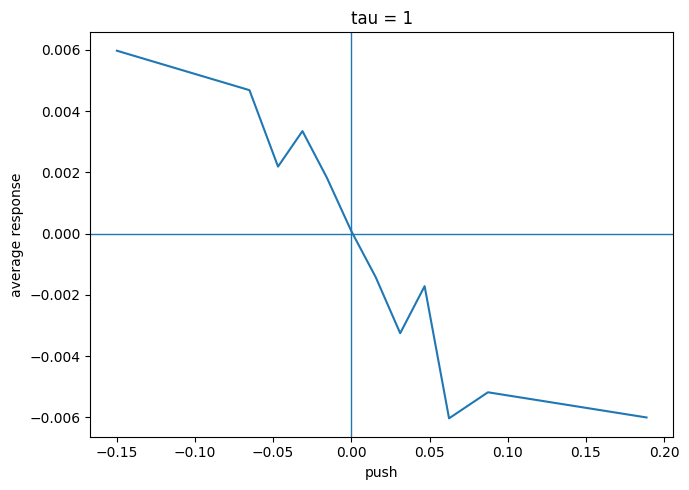

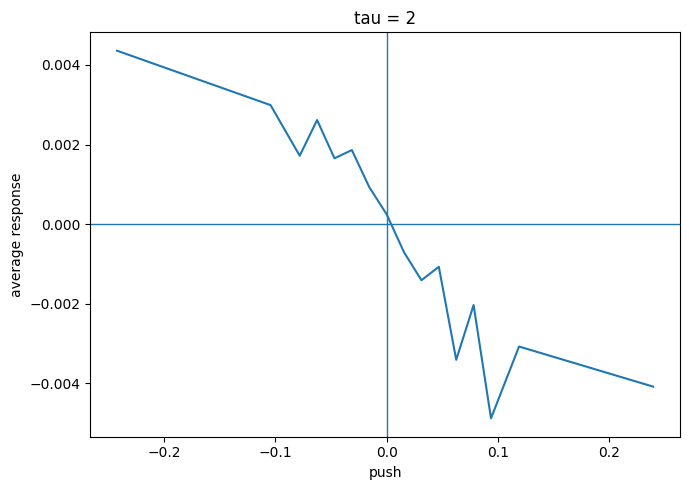

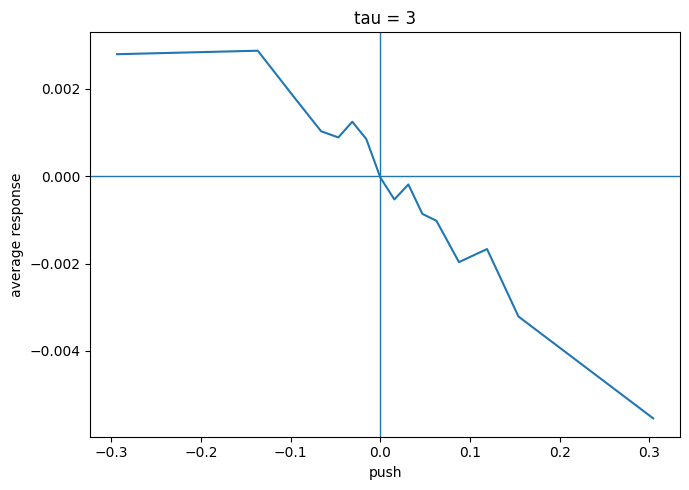

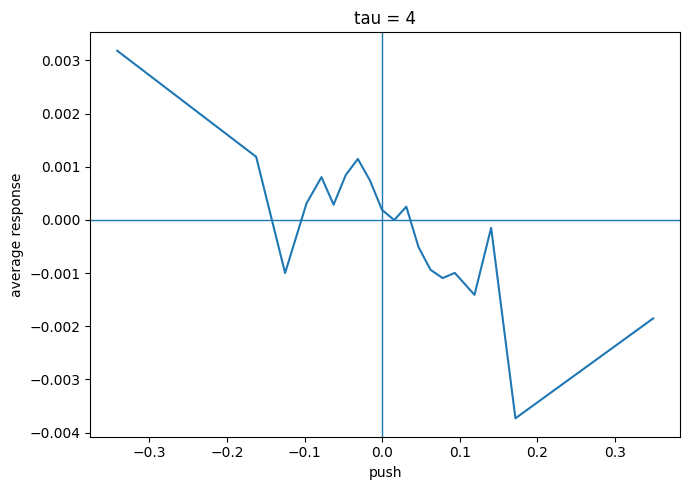

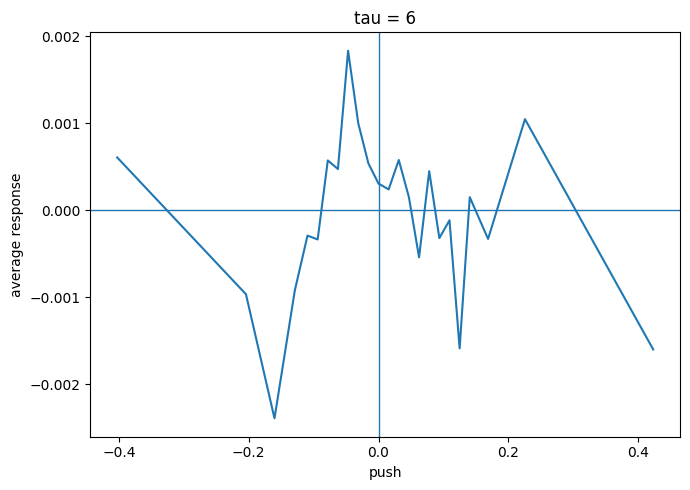

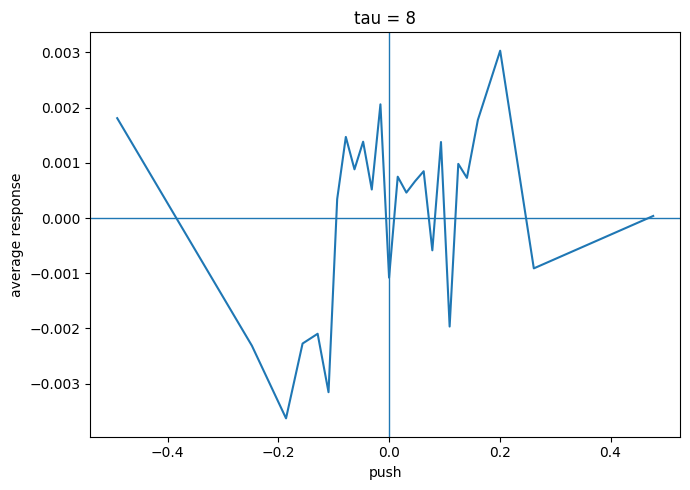

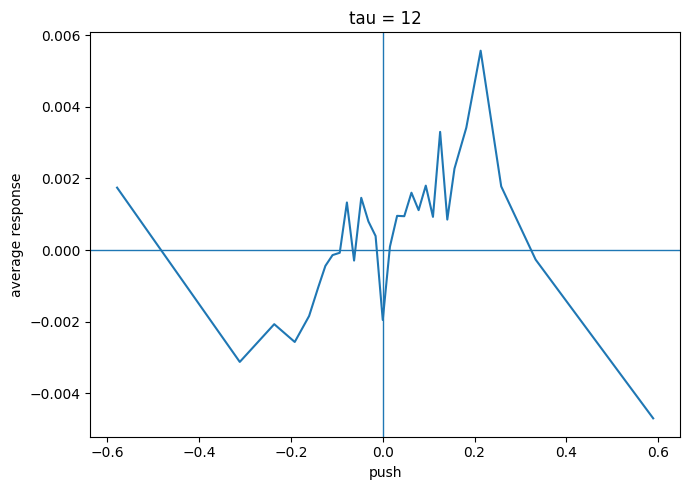

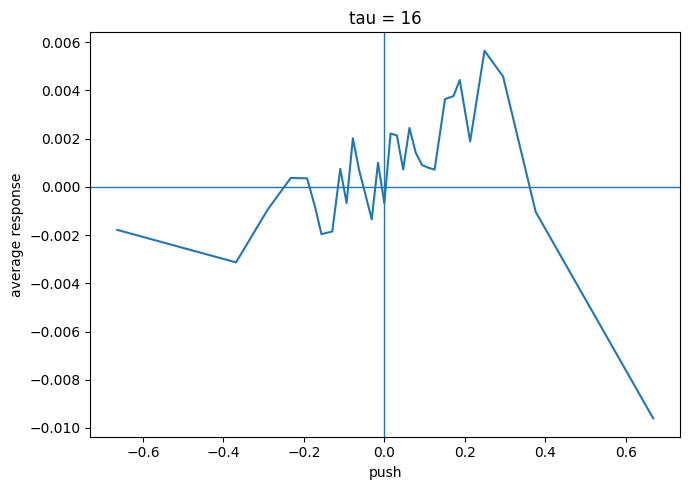

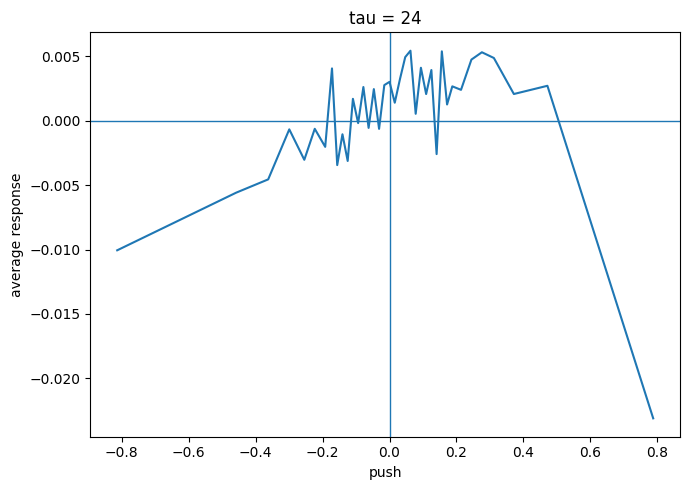

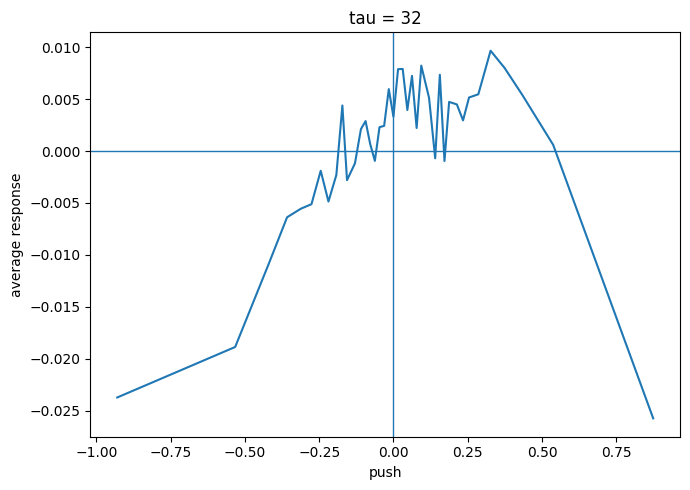

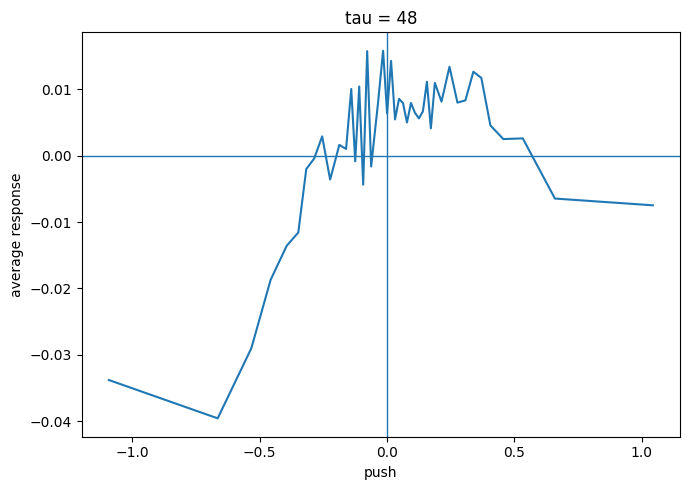

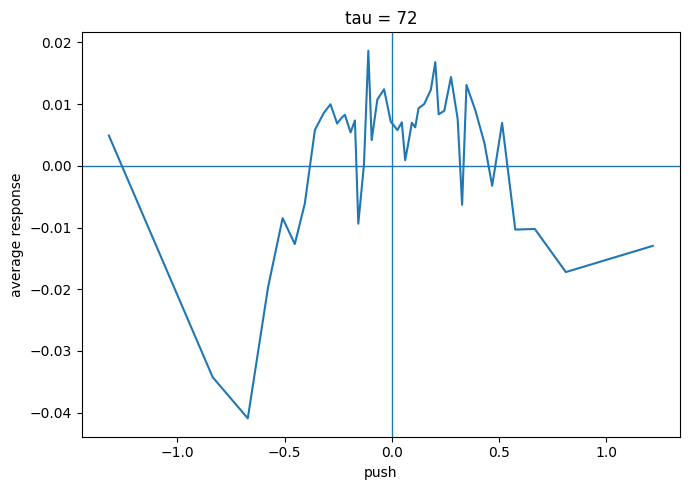

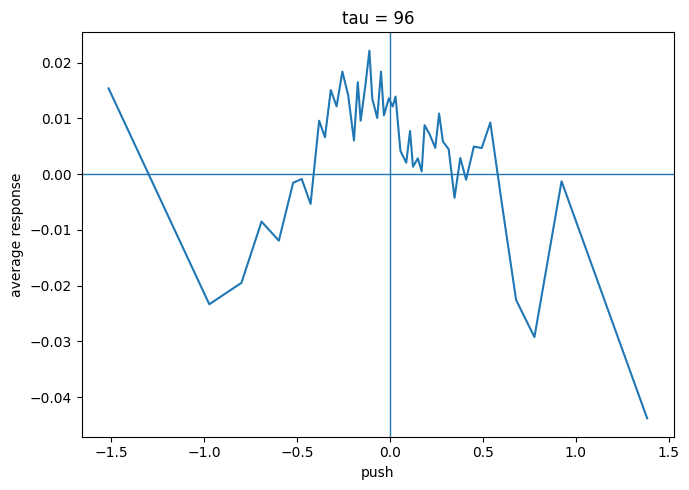

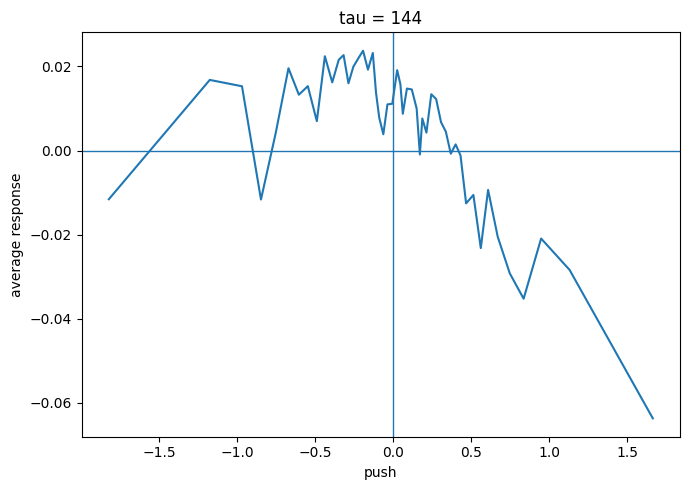

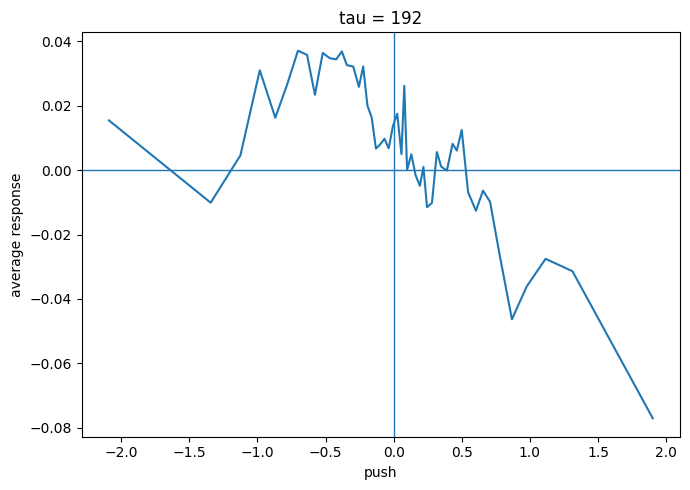

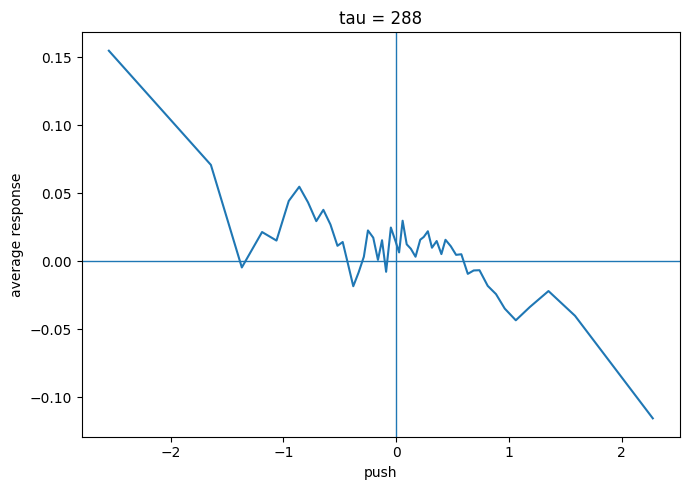

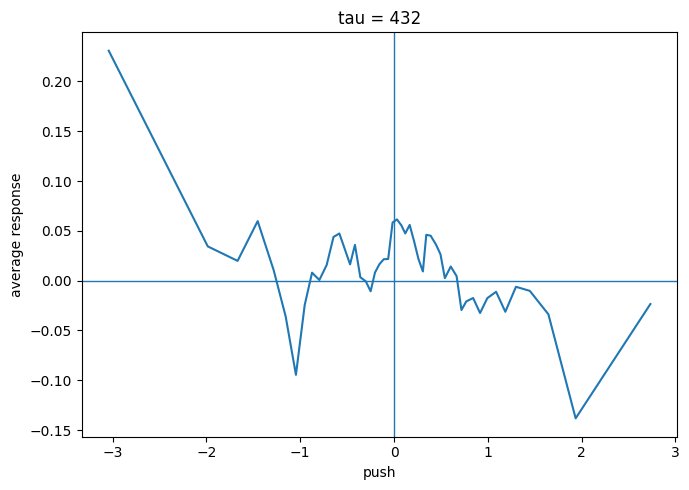

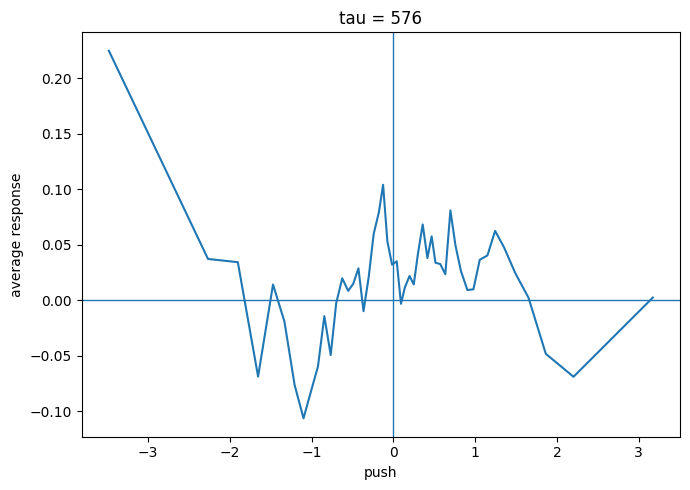

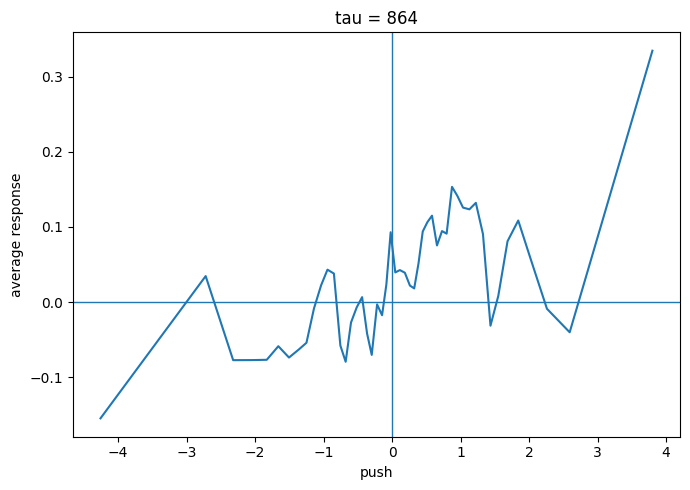

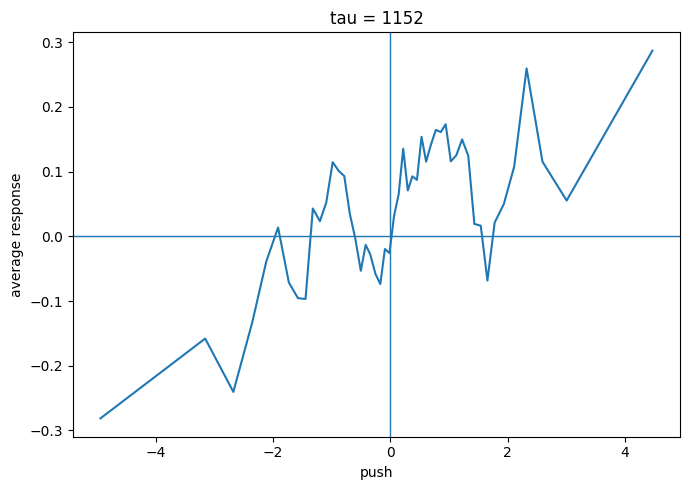

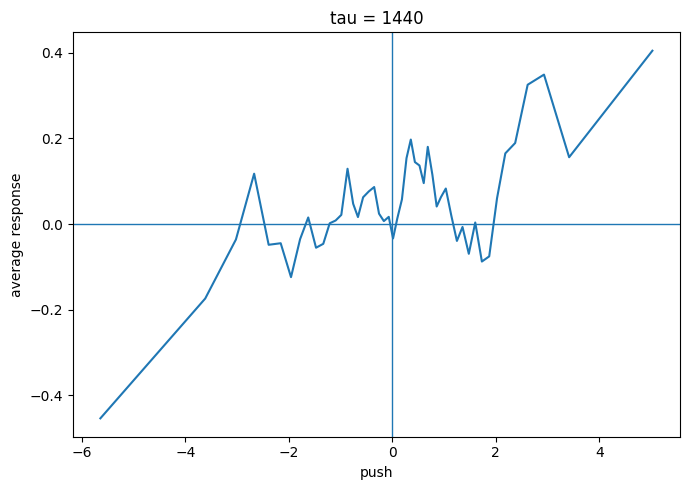

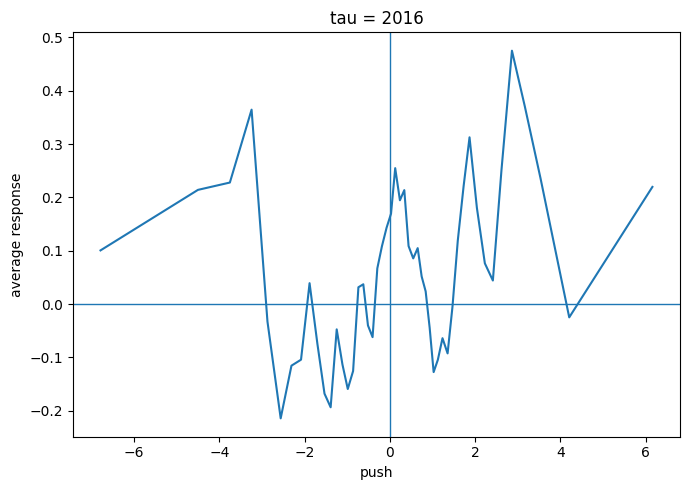

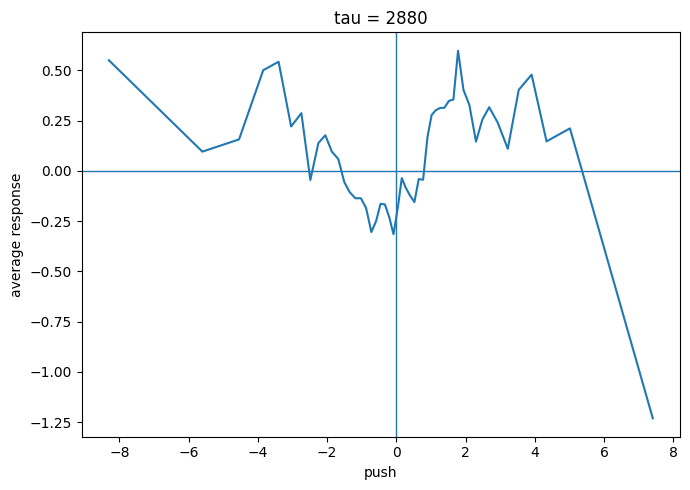

q=  1, VR = 1.0000
q=  2, VR = 0.9538
q=  3, VR = 0.9398
q=  4, VR = 0.9326
q=  5, VR = 0.9289
q=  6, VR = 0.9268
q=  7, VR = 0.9261
q=  8, VR = 0.9256
q=  9, VR = 0.9256
q= 10, VR = 0.9255
q= 11, VR = 0.9255
q= 12, VR = 0.9258
q= 13, VR = 0.9262
q= 14, VR = 0.9267
q= 15, VR = 0.9268
q= 16, VR = 0.9267
q= 17, VR = 0.9266
q= 18, VR = 0.9265
q= 19, VR = 0.9262
q= 20, VR = 0.9260
q= 21, VR = 0.9257
q= 22, VR = 0.9253
q= 23, VR = 0.9251
q= 24, VR = 0.9249
q= 25, VR = 0.9247
q= 26, VR = 0.9245
q= 27, VR = 0.9245
q= 28, VR = 0.9245
q= 29, VR = 0.9245
q= 30, VR = 0.9246
q= 31, VR = 0.9246
q= 32, VR = 0.9247
q= 33, VR = 0.9248
q= 34, VR = 0.9247
q= 35, VR = 0.9247
q= 36, VR = 0.9246
q= 37, VR = 0.9246
q= 38, VR = 0.9245
q= 39, VR = 0.9244
q= 40, VR = 0.9244
q= 41, VR = 0.9245
q= 42, VR = 0.9246
q= 43, VR = 0.9246
q= 44, VR = 0.9248
q= 45, VR = 0.9250
q= 46, VR = 0.9253
q= 47, VR = 0.9256
q= 48, VR = 0.9260
q= 49, VR = 0.9264
q= 50, VR = 0.9269
q= 51, VR = 0.9274
q= 52, VR = 0.9278
q= 53, VR = 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
TYdata = pd.read_csv("TY-5minHLV.csv")
TYdata["numTime"] = pd.to_datetime(TYdata["Date"].astype(str)+" "+TYdata["Time"].astype(str))
TYdata = TYdata.reset_index(drop=True)


p = TYdata["Close"].dropna()
p =p.shift(-1)

from time_series_analysis import (push_response_test, variance_test)
if __name__ == "__main__":
    tau_list = [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48,

                72, 96, 144, 192, 288, 432, 576,

                864, 1152, 1440, 2016, 2880]

    for i in tau_list:
        push_response = push_response_test(price=TYdata,tau=i)
        plt.figure(figsize=(7,5))
        plt.plot(push_response["push_mean"],push_response["response_mean"])
        plt.axhline(0,linewidth=1)
        plt.axvline(0,linewidth=1)
        plt.xlabel("push")
        plt.ylabel("average response")
        plt.title(f"tau = {i}")
        plt.tight_layout()
        plt.show()

    q_list = np.arange(1,300,1)
    vr_list = []

    for q in q_list:
        vr=variance_test(TYdata,q)
        vr_list.append(vr)
        print(f"q={q:>3}, VR = {vr:.4f}")